# Preparation & Preprocessing

## Data Acquisition

### Preparation

#### Imports

In [14]:
from nyc_taxi_routes.notebook import *
setup_plotting()

✓  wgnd theme activated (matplotlib · seaborn)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Constants

In [15]:
DATA_PATH = PATHS["interim"]
DATA_FILE= 'ny-taxi-routes_eda.parquet'

### Data Gathering

In [16]:
df_eda = df = pd.read_parquet(DATA_PATH / DATA_FILE, engine='pyarrow')

df_prep = df_eda.copy()

df_prep.head()

,pickup_weekday,pickup_hour,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,payment_type
0,3,19,-73.789970,40.646660,-74.005051,40.748081,1,18.610001,52.0,10.00,5.54,1
1,5,3,-73.986237,40.746513,-73.996796,40.742504,1,0.990000,5.0,1.00,0.00,1
2,4,20,-73.874634,40.773960,-73.959923,40.762802,3,9.250000,26.5,8.34,5.54,1
3,5,2,-73.952477,40.772064,-73.949371,40.675156,1,9.200000,28.0,0.00,0.00,2
4,4,21,-73.988281,40.764488,-73.996513,40.753239,1,0.900000,5.0,1.26,0.00,1


## Data Cleaning

In [4]:
# Remove duplicates and invalid data
df_prep = clean_data(df_prep)


───  DATA CLEANING:  ─────────────────────────────────────────
---  Duplicates: 24 exact rows removed
---  Finance: 246 invalid/outlier rows identified
---  Physics: 1796 invalid/outlier rows identified
---  Distance: 4 invalid/outlier rows identified
---  Geography: 5306 invalid/outlier rows identified
---  Logic: 1 invalid/outlier rows identified
 
✓  Cleaning complete. Total rows removed: 6631. Remaining rows for analysis: 293369.


## Outlier Handling


───  OUTLIERS  ───────────────────────────────────────────────


,column,mean,median,mean_med_diff,lower_1.5x,upper_1.5x,outliers_1.5x,outliers_1.5x_%,lower_3x,upper_3x,outliers_3x,outliers_3x_%
0,passenger_count,1.662,1.000,0.662,-0.500,3.500,31031,10.58%,-2.000,5.000,9971,3.40%
1,trip_distance,2.857,1.680,1.177,-2.090,6.150,30681,10.46%,-5.180,9.240,17694,6.03%
2,total_yield,14.058,10.500,3.558,-5.600,28.960,24879,8.48%,-18.560,41.920,11476,3.91%
3,fare_amount,12.297,9.000,3.297,-4.750,25.250,24855,8.47%,-16.000,36.500,10913,3.72%
4,pickup_longitude,-73.974,-73.982,0.008,-74.028,-73.932,15192,5.18%,-74.064,-73.896,13134,4.48%
5,tip_amount,1.760,1.350,0.410,-3.525,5.875,14537,4.96%,-7.050,9.400,5550,1.89%
6,dropoff_longitude,-73.974,-73.980,0.006,-74.033,-73.922,14475,4.93%,-74.075,-73.880,8914,3.04%
7,tolls_amount,0.281,0.000,0.281,0.000,0.000,13874,4.73%,0.000,0.000,13874,4.73%
8,has_tolls,0.047,0.000,0.047,0.000,0.000,13874,4.73%,0.000,0.000,13874,4.73%
9,dropoff_latitude,40.752,40.754,-0.002,40.685,40.820,13738,4.68%,40.635,40.871,1519,0.52%


→ inspect_outlier_detail(df, col) for boxplot+histogram per feature.


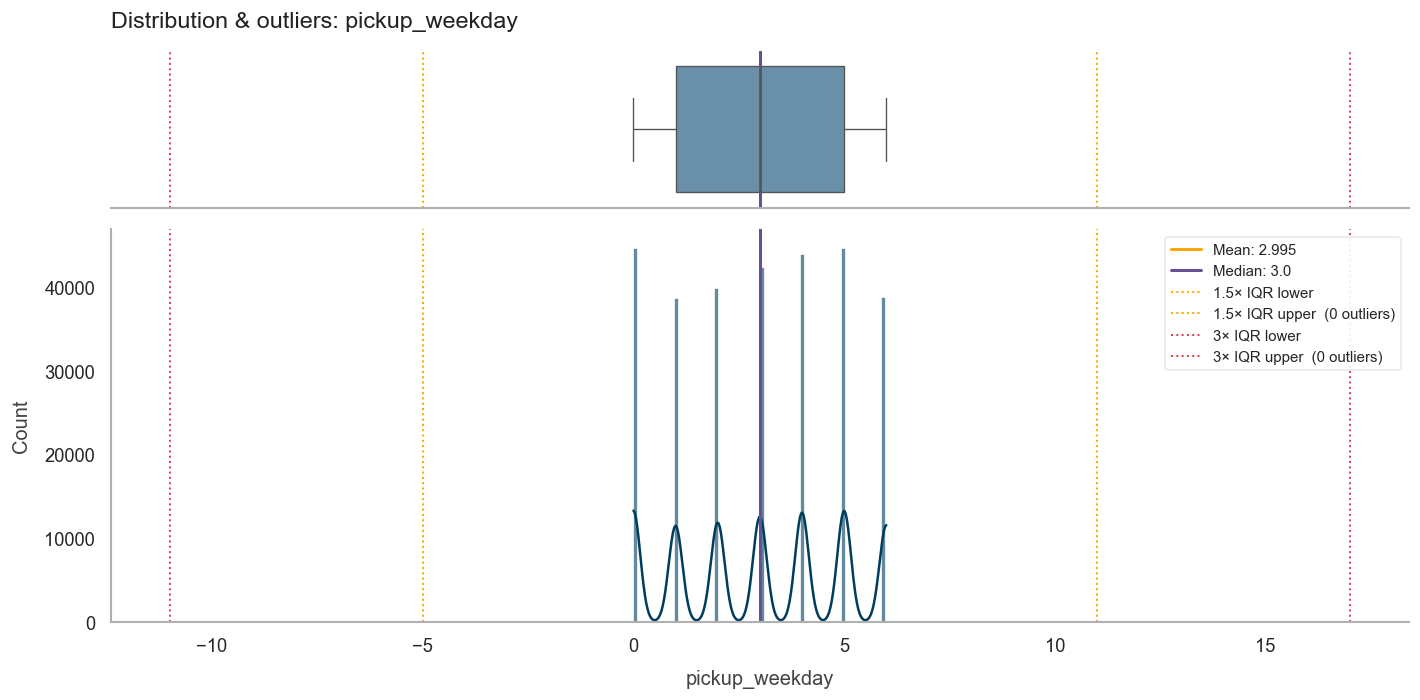

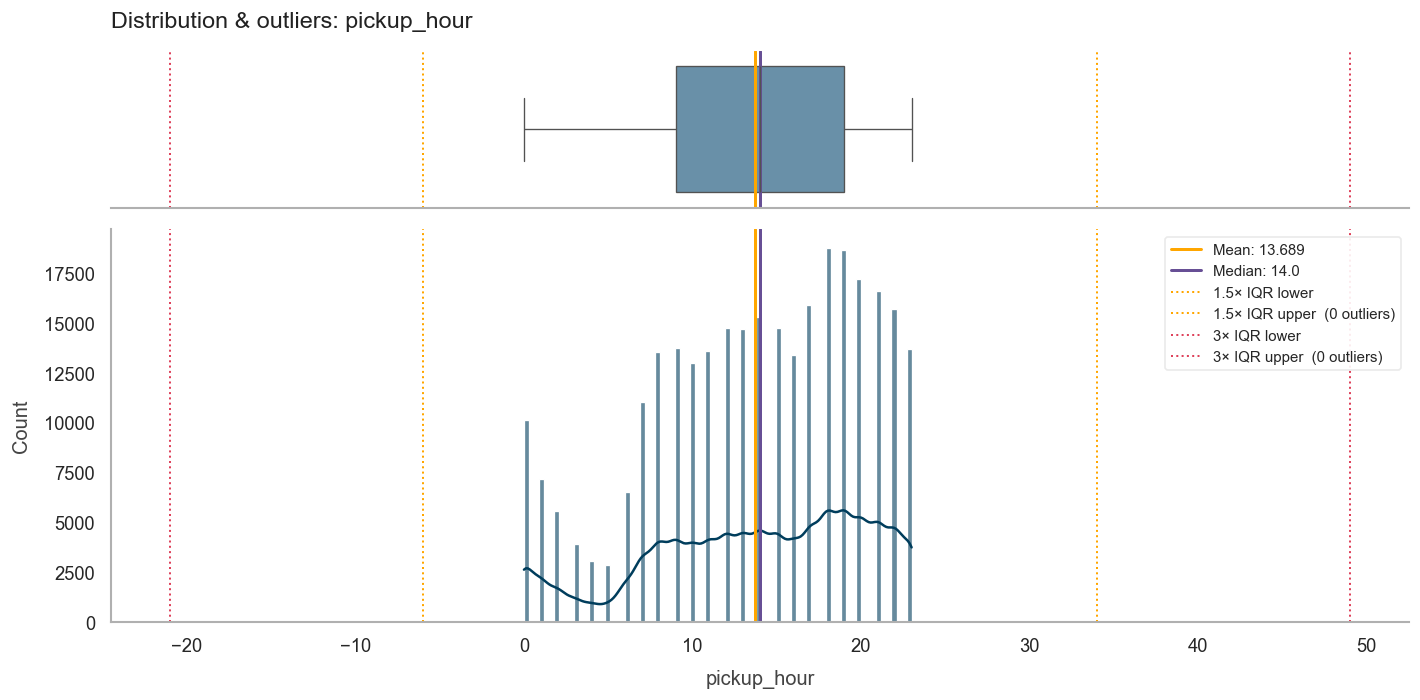

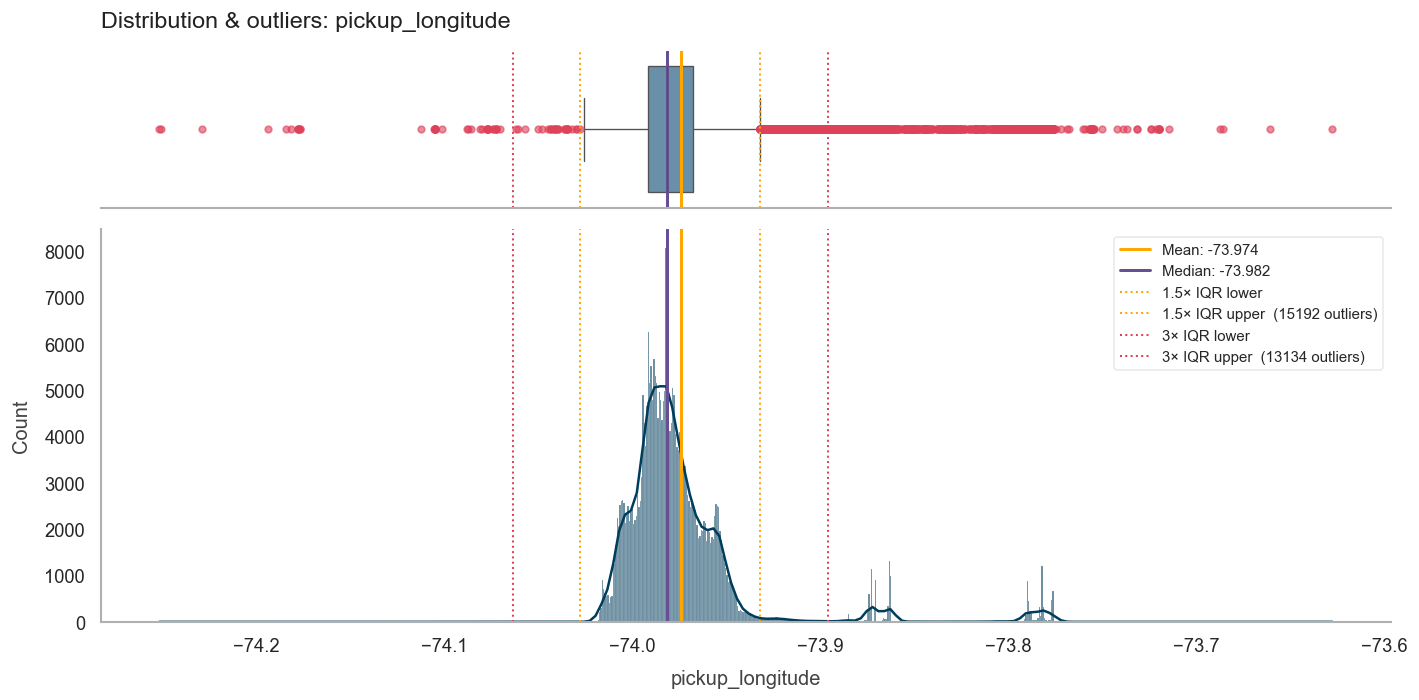

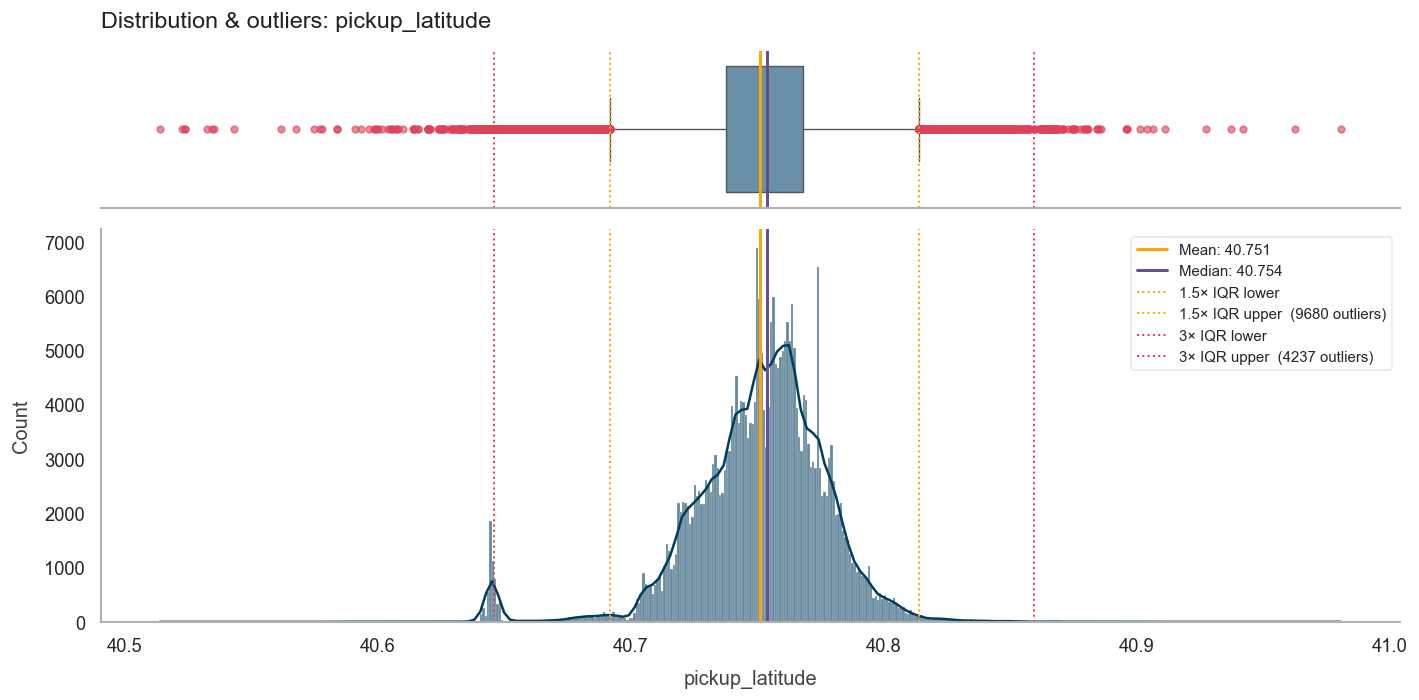

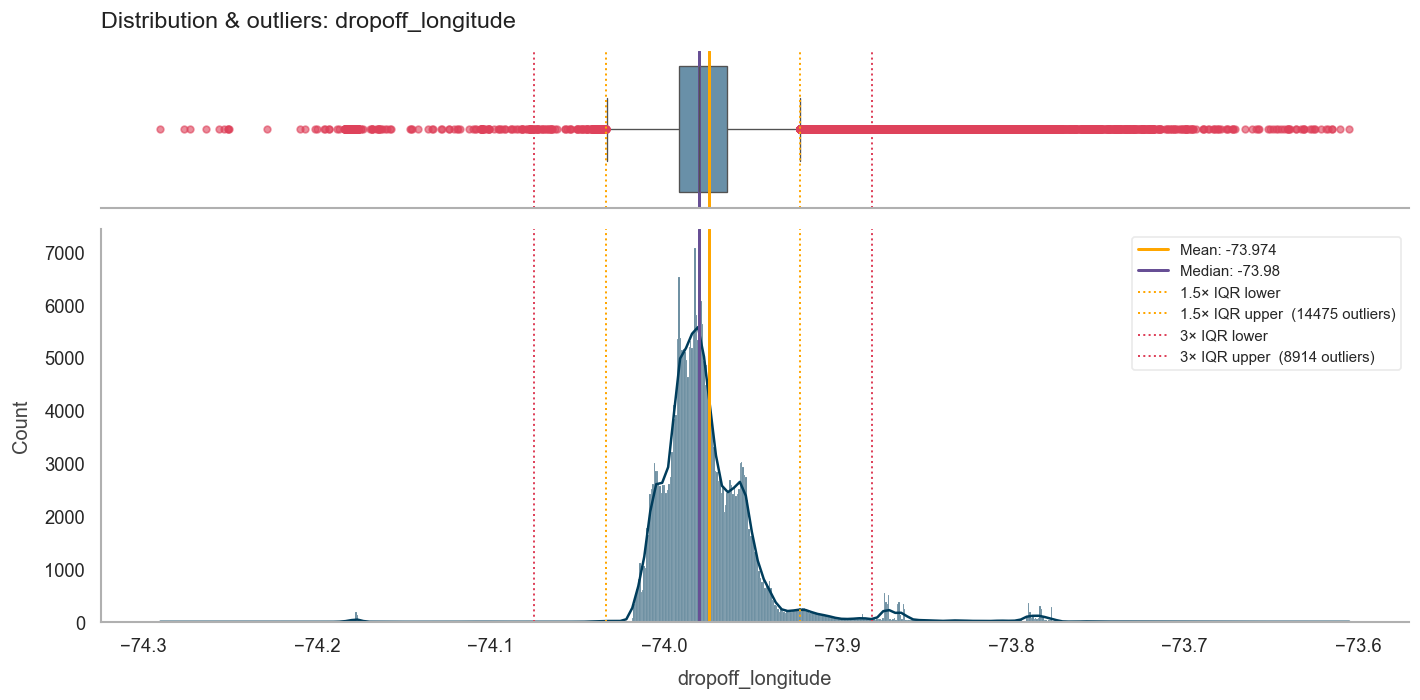

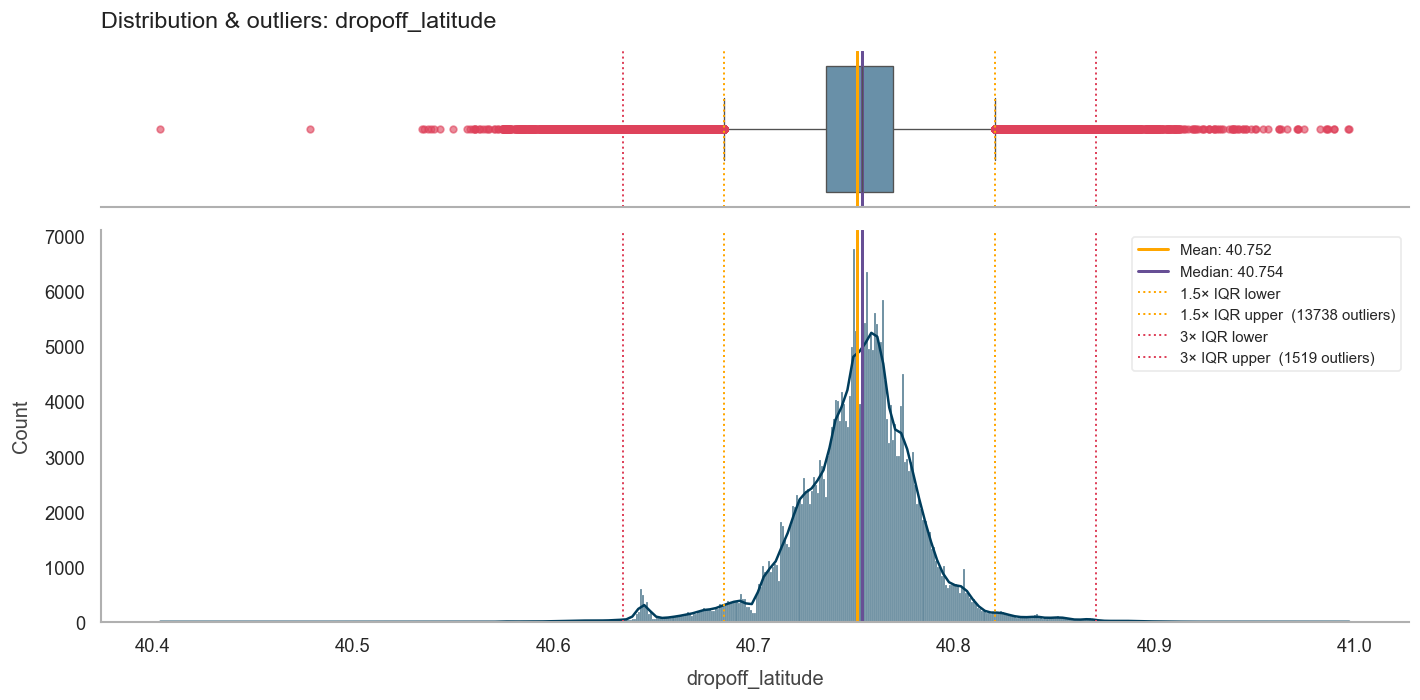

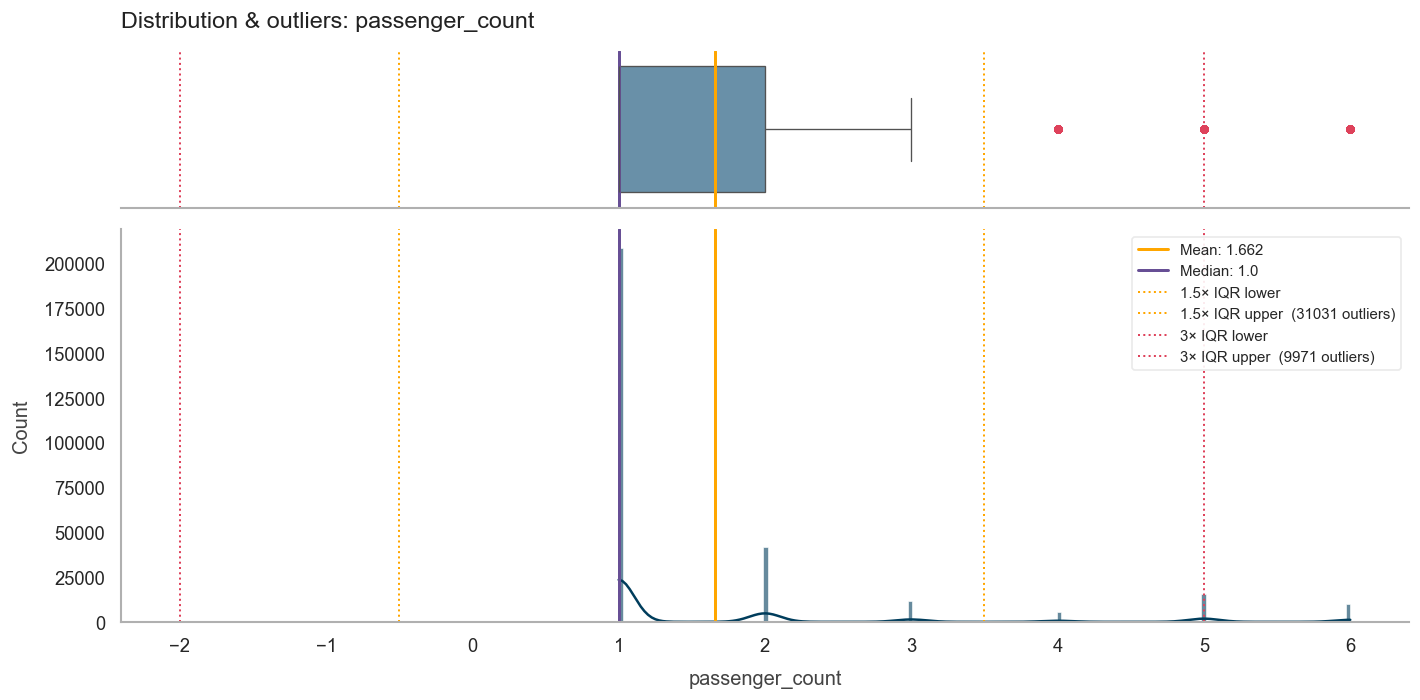

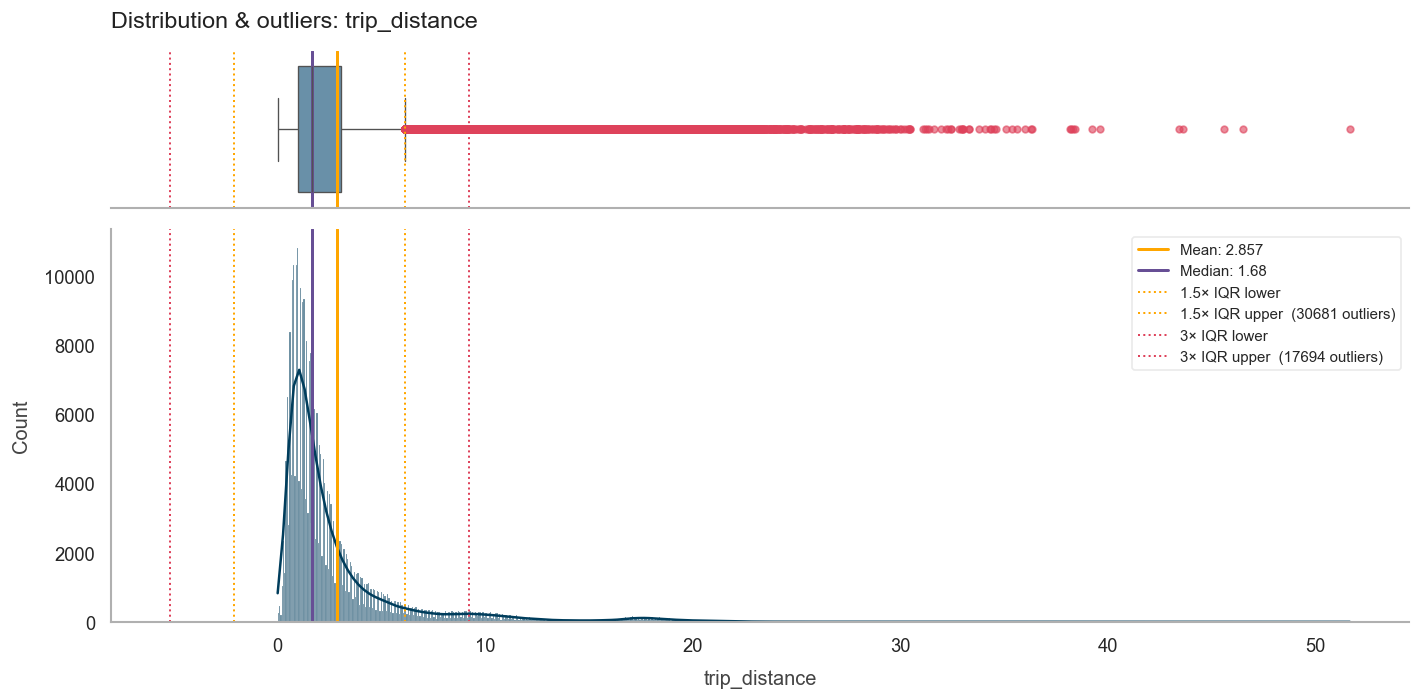

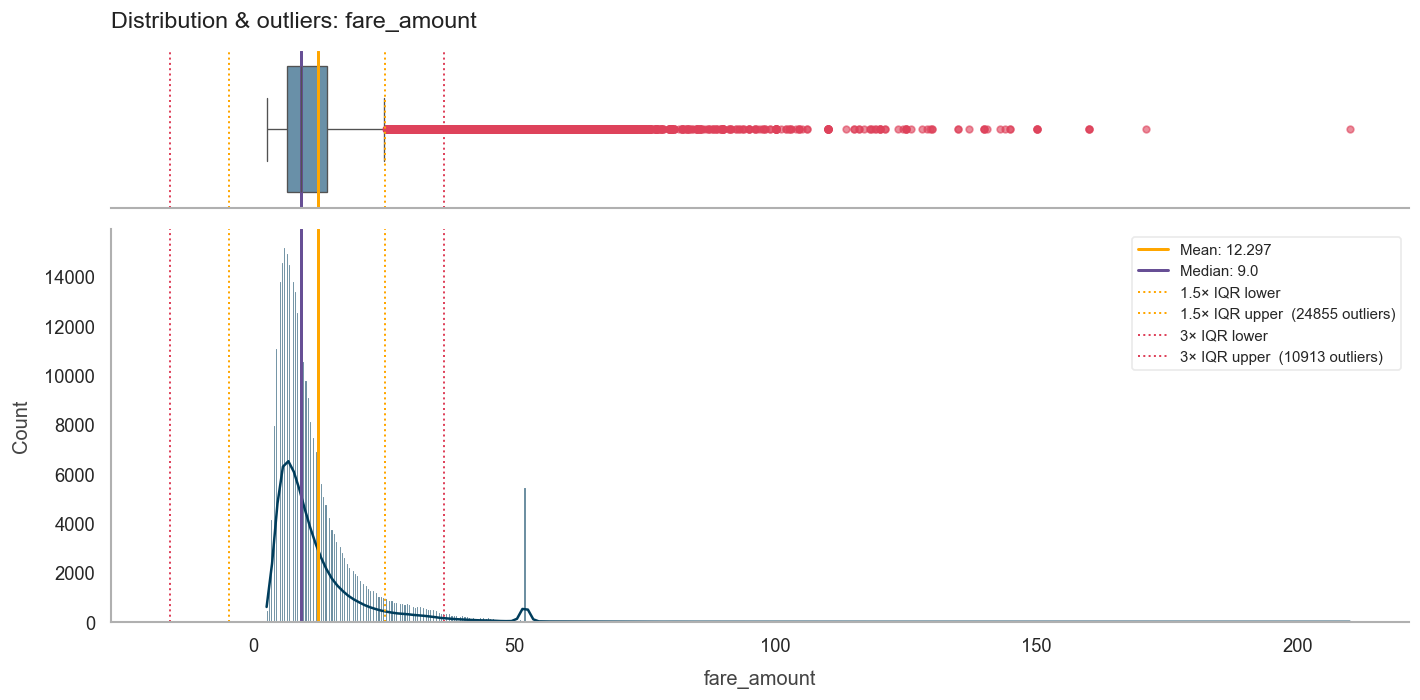

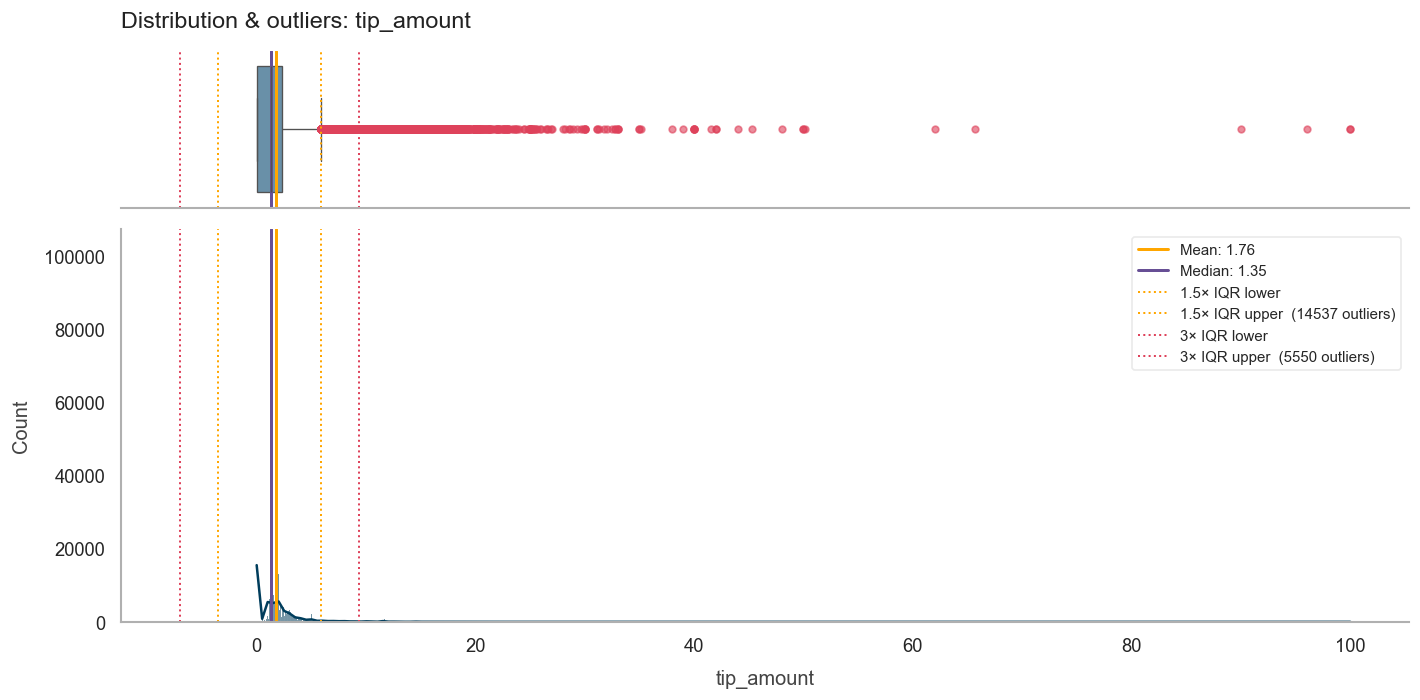

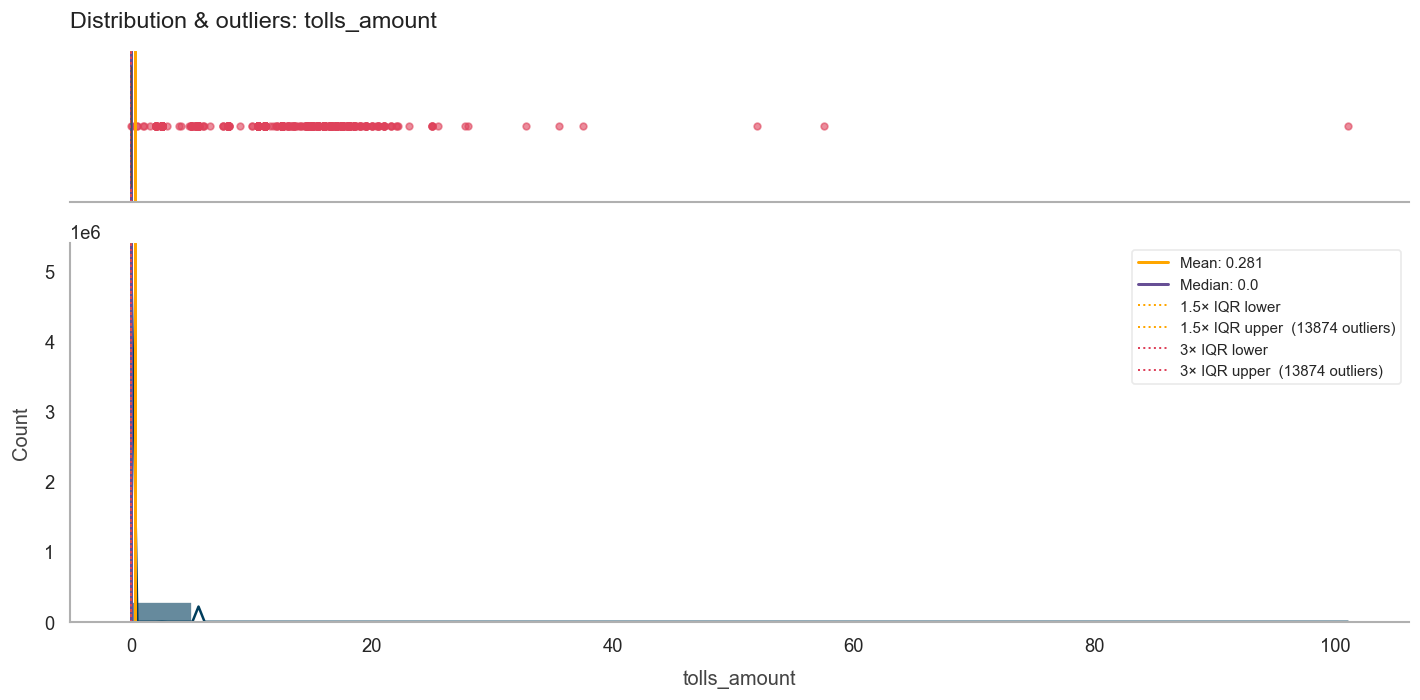

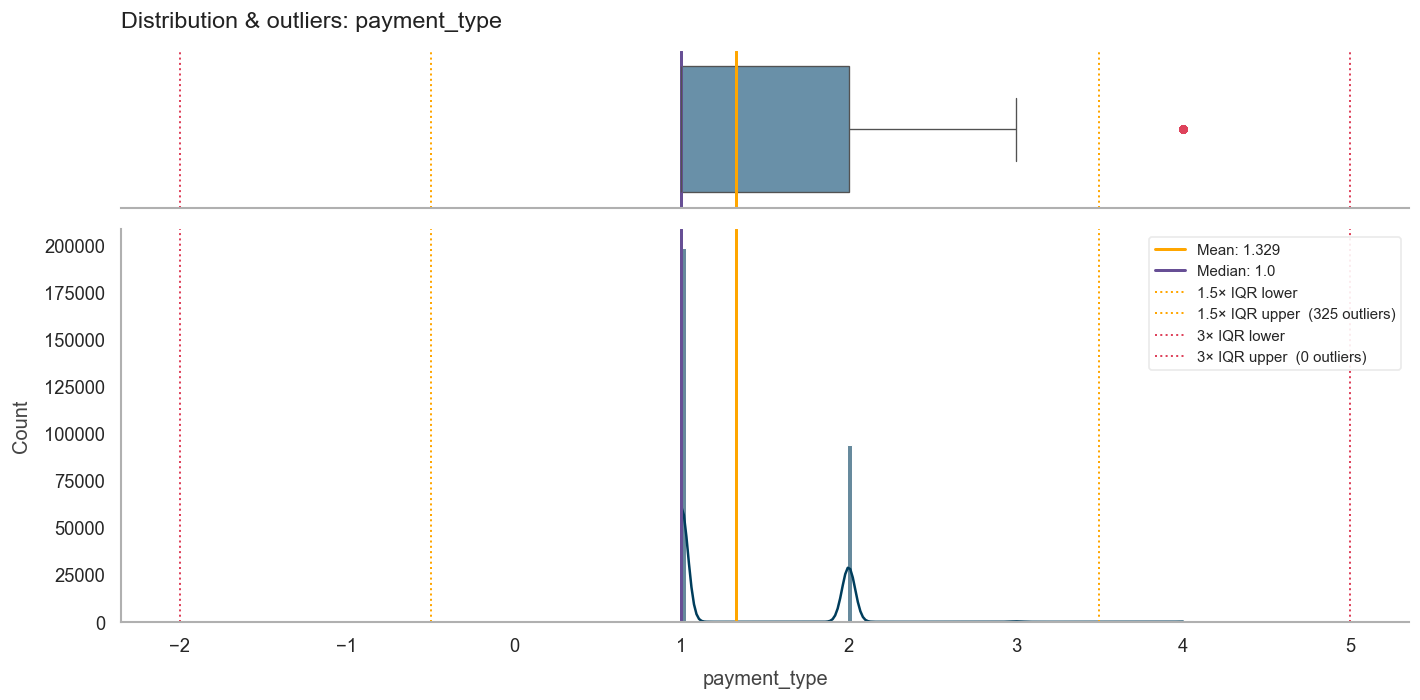

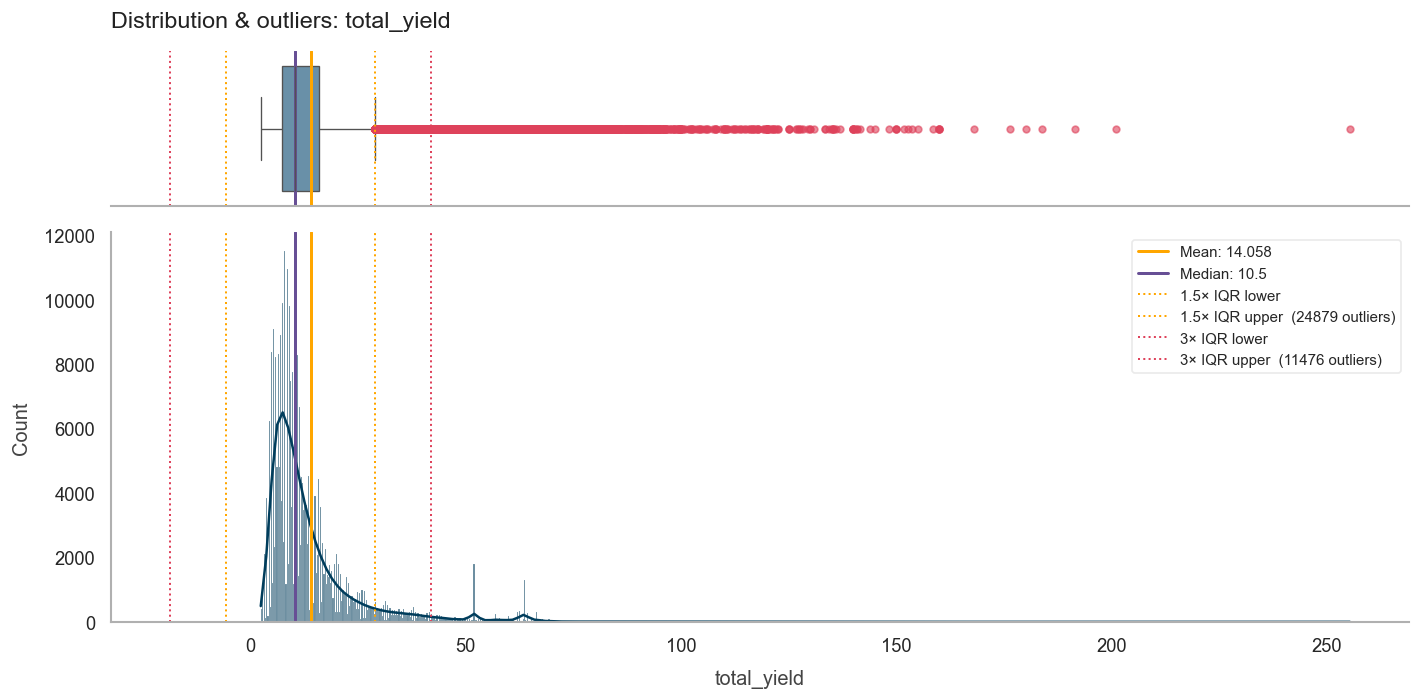

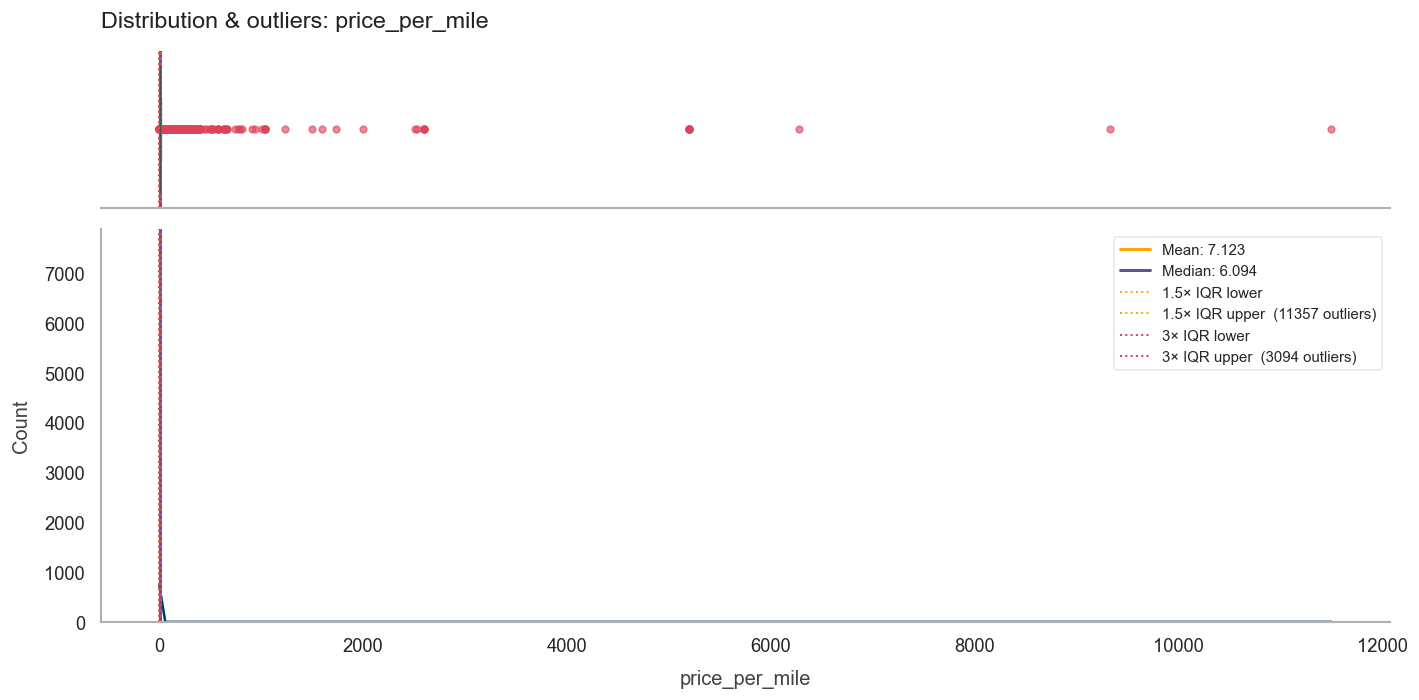

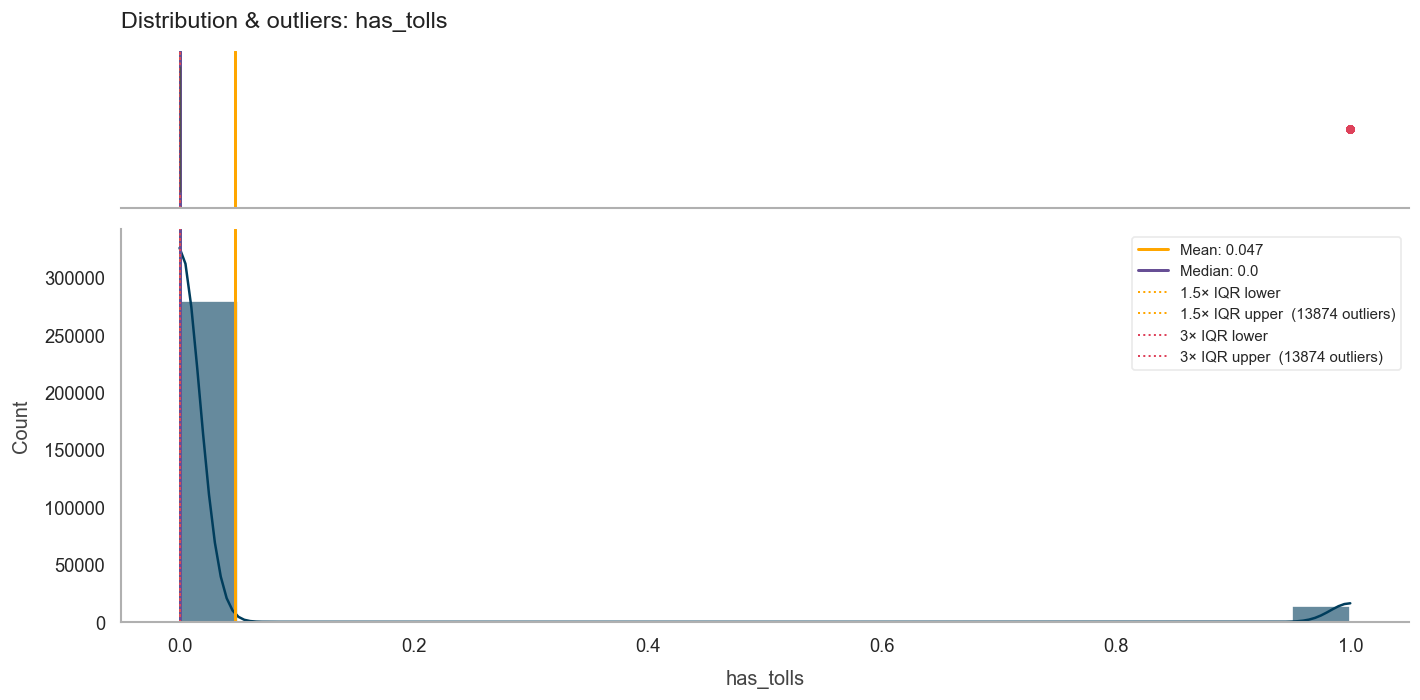

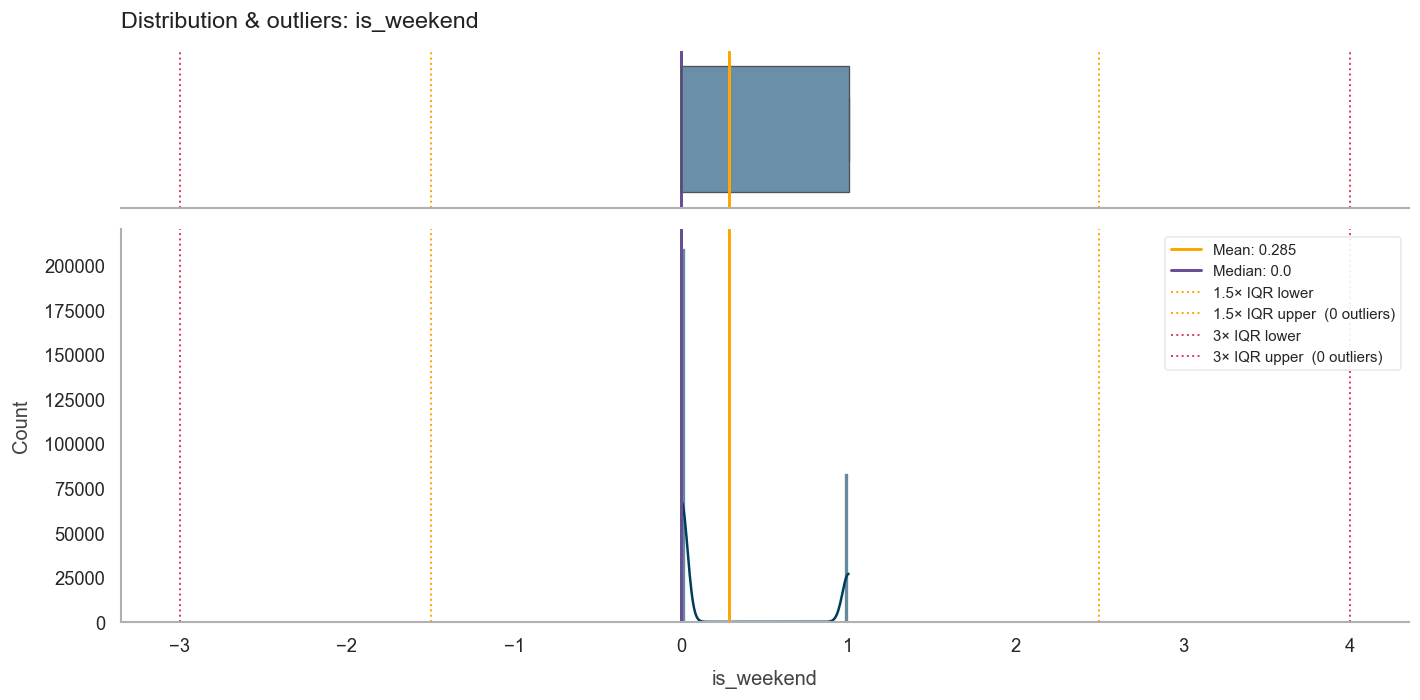

In [ ]:
# Platzhalter: IQR-Masken, Extremwerte kappen
#inspect_outliers(df_prep)


#for feat in df_prep.select_dtypes(include=[np.number]).columns:
#    inspect_outlier_detail(df_prep, feat)



## Feature Engineering

In [7]:
# Add new features
df_prep = add_features(df_prep)


───  FEATURE ENGINEERING:   ──────────────────────────────────
---  Adding Geo-Location & Routes...
---  Adding Economic Metrics (Yield, Price per Mile)...
---  Adding Temporal Features (Time Slots, Weekend-Flag)...
 
✓  Feature Engineering complete. New columns added.


## Data Inspection


───  MEMORY  ─────────────────────────────────────────────────


,column,dtype,memory_kb,memory_pct
0,pickup_weekday,int64,2291.945,8.51%
1,pickup_hour,int64,2291.945,8.51%
2,is_weekend,int64,2291.945,8.51%
3,payment_type,int64,2291.945,8.51%
4,has_tolls,int64,2291.945,8.51%
5,pickup_longitude,float32,1145.973,4.25%
6,pickup_latitude,float32,1145.973,4.25%
7,dropoff_longitude,float32,1145.973,4.25%
8,tip_amount,float32,1145.973,4.25%
9,fare_amount,float32,1145.973,4.25%


Total: 26932.151 KB  (26.301 MB)

───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,293369,
1,columns,20,
2,duplicates,0,0.0%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  DTYPES  ─────────────────────────────────────────────────


...

,column,missing_pct,count,mean,median,std,min,25%,75%,max,mean_median_diff,skewness
0,pickup_weekday,0.00%,293369.000,2.995,3.000,1.997,0.000,1.000,5.000,6.000,-0.005,-0.038
1,pickup_hour,0.00%,293369.000,13.689,14.000,6.313,0.000,9.000,19.000,23.000,-0.311,-0.463
2,pickup_longitude,0.00%,293369.000,-73.974,-73.982,0.036,-74.252,-73.992,-73.968,-73.628,0.008,3.387
3,pickup_latitude,0.00%,293369.000,40.751,40.754,0.027,40.514,40.738,40.768,40.981,-0.003,-1.069
4,dropoff_longitude,0.00%,293369.000,-73.974,-73.980,0.034,-74.290,-73.991,-73.964,-73.605,0.006,2.494
5,dropoff_latitude,0.00%,293369.000,40.752,40.754,0.032,40.404,40.736,40.770,40.997,-0.002,-0.436
6,passenger_count,0.00%,293369.000,1.662,1.000,1.317,1.000,1.000,2.000,6.000,0.662,2.141
7,trip_distance,0.00%,293369.000,2.857,1.680,3.468,0.010,1.000,3.060,51.650,1.177,3.057
8,fare_amount,0.00%,293369.000,12.297,9.000,9.954,2.500,6.500,14.000,210.000,3.297,2.876
9,tip_amount,0.00%,293369.000,1.760,1.350,2.313,0.000,0.000,2.350,100.000,0.410,4.129



───  CATEGORICAL STATS  ──────────────────────────────────────


,column,missing_pct,missing_cnt,uniques,top_value,top_value_cnt,top_value_freq_pct
0,departure,0.00%,0,3,NYC,287689,98.06%
1,arrival,0.00%,0,3,NYC,290620,99.06%
2,route,0.00%,0,8,NYC-NYC,285174,97.21%
3,time_slot,0.00%,0,4,Night,85159,29.03%



───  ROUTES  ─────────────────────────────────────────────────
New features helping discover the rout distribution


,trip_sum
route,
JFK-JFK,143
JFK-NYC,5445
JFK-OTHER,61
NYC-JFK,1964
NYC-NYC,285174
NYC-OTHER,551
OTHER-NYC,1
OTHER-OTHER,30


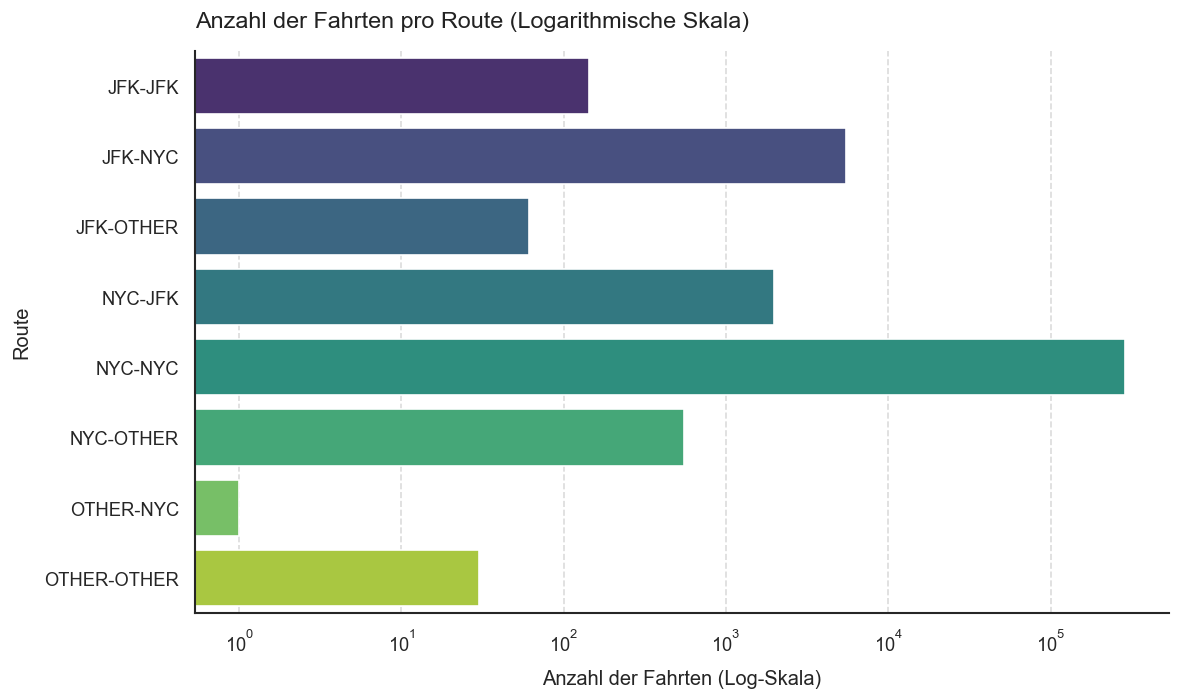

In [10]:
result = inspect(df_prep, sections=['memory', 'dimensions', 'dtypes', 'numeric', 'categorical'])


df_routes = df_prep.groupby(by="route", observed=True).agg(
    trip_sum=("trip_distance", "count")
)

section_header('Routes')
log("New features helping discover the rout distribution")
show_df(df_routes)

df_sorted = df_routes.sort_values('trip_sum', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_sorted, x='trip_sum', y='route', palette='viridis', hue='route', legend=False)
ax.set_xscale("log")

plt.title('Anzahl der Fahrten pro Route (Logarithmische Skala)', fontsize=14)
plt.xlabel('Anzahl der Fahrten (Log-Skala)', fontsize=12)
plt.ylabel('Route', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend=False
plt.tight_layout()
plt.savefig('../public/img/route_distribution_log.png')


## Data Export

In [11]:
df_prep.to_parquet(PATHS["processed"] / f"ny-taxi-routes_prep.parquet", engine='pyarrow')